In [1]:
import sys, sklearn
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
scikit-learn: 1.6.1


In [3]:
import pandas as pd

file_path = "/content/drive/My Drive/skim_coat_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (3000, 9)


,WallSize_sqft,PricePerSqft_LKR,Location,Brand,SurfaceType,SurfaceCondition,FinishLevel,MoistureLevel,DurabilityRequirement
0,768,750,indoor,Multilac Skim Coat,old wall,repaired,basic,medium,high
1,389,750,indoor,INSEE Skim Coat,concrete,repaired,basic,medium,medium
2,876,1000,outdoor,Tokyo plaster master,concrete,new,ultra smooth,medium,medium
3,968,1000,indoor,INSEE Skim Coat,cement plaster,repaired,ultra smooth,medium,high
4,703,1000,indoor,INSEE Skim Coat,old wall,new,basic,high,low


In [4]:
df.columns

Index(['WallSize_sqft', 'PricePerSqft_LKR', 'Location', 'Brand', 'SurfaceType',
       'SurfaceCondition', 'FinishLevel', 'MoistureLevel',
       'DurabilityRequirement'],
      dtype='object')

In [5]:
# Clean whitespace in categorical columns
text_cols = [
    "Location","Brand","SurfaceType","SurfaceCondition",
    "FinishLevel","MoistureLevel","DurabilityRequirement"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Check missing values
print("Missing values per column:")
print(df.isna().sum())

# Check class distribution (important for fairness)
print("\nBrand distribution:")
print(df["Brand"].value_counts())


Missing values per column:
WallSize_sqft            0
PricePerSqft_LKR         0
Location                 0
Brand                    0
SurfaceType              0
SurfaceCondition         0
FinishLevel              0
MoistureLevel            0
DurabilityRequirement    0
dtype: int64

Brand distribution:
Brand
Tokyo plaster master      772
INSEE Skim cement Coat    742
NIPPOFLEX skim coat       198
SF Skim Coat              191
Swisstek Skim Coat        188
Maxbond Skim Coat         188
Multilac Skim Coat        186
ASIANPAINT Skim Coat      185
INSEE Skim Coat           181
NIPPON skim coat          169
Name: count, dtype: int64


In [9]:
#Define features (X) and target (y)
#Purpose - Separate input variables from the prediction target (Brand).
# Features used for prediction
X = df.drop(columns=["Brand"])

# Target variable (what we want to predict)
y = df["Brand"]

print("Input features:", list(X.columns))
print("Target variable:", y.name)


Input features: ['WallSize_sqft', 'PricePerSqft_LKR', 'Location', 'SurfaceType', 'SurfaceCondition', 'FinishLevel', 'MoistureLevel', 'DurabilityRequirement']
Target variable: Brand


In [11]:
#Train / Test split
from sklearn.model_selection import train_test_split

# Stratified split keeps brand proportions consistent
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (2400, 8)
Testing samples: (600, 8)


In [12]:
#Preprocessing pipeline
#Purpose:

#Scale numeric data

#One-hot encode categorical data

#Prevent data leakage using pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numeric and categorical columns
numeric_features = ["WallSize_sqft", "PricePerSqft_LKR"]
categorical_features = [c for c in X.columns if c not in numeric_features]

# ColumnTransformer applies correct preprocessing to each column type
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['WallSize_sqft', 'PricePerSqft_LKR']
Categorical features: ['Location', 'SurfaceType', 'SurfaceCondition', 'FinishLevel', 'MoistureLevel', 'DurabilityRequirement']


In [13]:
#Define algorithms to compare
#Purpose:
#Compare linear, tree-based, and boosting models to find the best performe

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

models


{'Logistic Regression': LogisticRegression(max_iter=3000),
 'Linear SVM': LinearSVC(),
 'Random Forest': RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42),
 'Gradient Boosting': HistGradientBoostingClassifier(random_state=42)}

In [15]:
from sklearn.pipeline import Pipeline

In [16]:
#Use 5-fold cross-validation to get reliable accuracy and Macro F1 scores.

from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    # Pipeline ensures preprocessing happens inside CV folds
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV Accuracy (Mean)": scores["test_accuracy"].mean(),
        "CV Accuracy (Std)": scores["test_accuracy"].std(),
        "CV Macro F1 (Mean)": scores["test_f1_macro"].mean(),
        "CV Macro F1 (Std)": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="CV Macro F1 (Mean)", ascending=False
)

results_df


,Model,CV Accuracy (Mean),CV Accuracy (Std),CV Macro F1 (Mean),CV Macro F1 (Std)
2,Random Forest,0.319167,0.016051,0.202244,0.020452
3,Gradient Boosting,0.305000,0.014530,0.197420,0.018606
1,Linear SVM,0.306250,0.021449,0.194872,0.026369
0,Logistic Regression,0.305000,0.020181,0.193422,0.023523


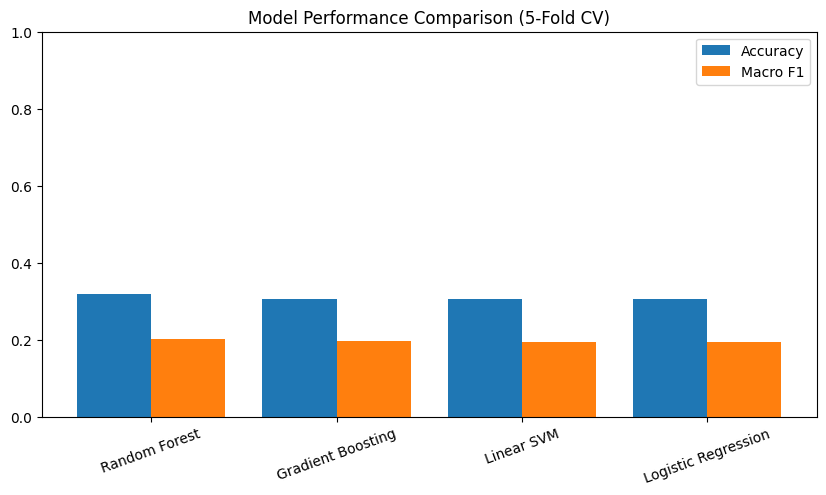

In [17]:
#Visual comparison chart

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results_df))

plt.figure(figsize=(10,5))
plt.bar(x - 0.2, results_df["CV Accuracy (Mean)"], width=0.4, label="Accuracy")
plt.bar(x + 0.2, results_df["CV Macro F1 (Mean)"], width=0.4, label="Macro F1")

plt.xticks(x, results_df["Model"], rotation=20)
plt.ylim(0, 1)
plt.title("Model Performance Comparison (5-Fold CV)")
plt.legend()
plt.show()


In [18]:
#Train the top-performing algorithm on the full training dataset.
from sklearn.pipeline import Pipeline

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

print("Selected model:", best_model_name)



Selected model: Random Forest


In [19]:
#Final test evaluation

from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = best_pipeline.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.31666666666666665
Test Macro F1: 0.2092071280194911

Classification Report:
                        precision    recall  f1-score   support

  ASIANPAINT Skim Coat       0.16      0.14      0.14        37
       INSEE Skim Coat       0.26      0.25      0.25        36
INSEE Skim cement Coat       0.49      0.55      0.52       148
     Maxbond Skim Coat       0.08      0.08      0.08        38
    Multilac Skim Coat       0.15      0.16      0.16        37
   NIPPOFLEX skim coat       0.07      0.07      0.07        40
      NIPPON skim coat       0.12      0.12      0.12        34
          SF Skim Coat       0.13      0.11      0.12        38
    Swisstek Skim Coat       0.15      0.18      0.16        38
  Tokyo plaster master       0.50      0.44      0.47       154

              accuracy                           0.32       600
             macro avg       0.21      0.21      0.21       600
          weighted avg       0.32      0.32      0.32       600



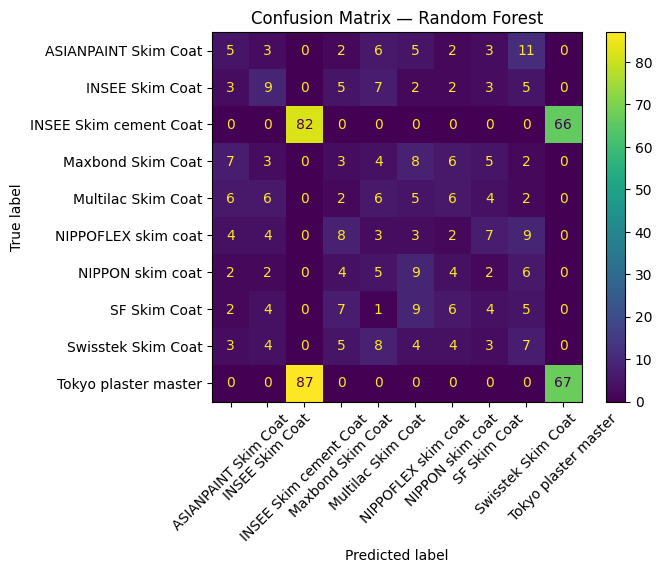

In [20]:
#Understand where the model makes correct vs incorrect brand predictions.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()



In [21]:
top = results_df.iloc[0]

print("FINAL MODEL SELECTION SUMMARY\n")
print(f"Chosen Algorithm: {best_model_name}")
print("Reason: Highest Macro F1 score, indicating balanced performance across all brands.")
print(f"Cross-validated Macro F1: {top['CV Macro F1 (Mean)']:.4f}")
print(f"Cross-validated Accuracy: {top['CV Accuracy (Mean)']:.4f}")


FINAL MODEL SELECTION SUMMARY

Chosen Algorithm: Random Forest
Reason: Highest Macro F1 score, indicating balanced performance across all brands.
Cross-validated Macro F1: 0.2022
Cross-validated Accuracy: 0.3192


In [22]:
def predict_brand(user_input):
    row = pd.DataFrame([user_input])
    row = row[X.columns]  # ensure correct column order
    return best_pipeline.predict(row)[0]

sample_input = {
    "WallSize_sqft": 400,
    "PricePerSqft_LKR": 75,
    "Location": "indoor",
    "SurfaceType": "concrete",
    "SurfaceCondition": "new",
    "FinishLevel": "smooth",
    "MoistureLevel": "low",
    "DurabilityRequirement": "high"
}

print("Predicted Brand:", predict_brand(sample_input))


Predicted Brand: Swisstek Skim Coat
